# **Pós Graduação - Ciência de Dados Aplicada à Análise de Risco**

## **Aprendizagem Máquina e Inteligência Artificial**
### **Redes Neuronais Recorrentes – Colocação em Funcionamento**

---

### **Sessão 2 — Fundamentos**
#### **2.4 — Dataset Dados Financeiros**

> Neste notebook vamos criar uma rede **LSTM** para predição de **dados financeiros**.  
>  
> Será demonstrado como
>> (1) Carregar dados de ativos financeiros, a partir da **Yahoo Finance**

>> (2) Normalização dos dados.

>> (3) Criação da rede.

>> (4) Treino da rede.

---
> *Prof. Sérgio D. Correia, Maio 2026 [2025/26, 2º Semestre]*

In [1]:
#Instalação de pacotes
!pip install yfinance --quiet

In [2]:
#Importações
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
#Carregar dados (apenas fecho)
dados = yf.download('AAPL', period='1y')
fecho = dados[['Close']]

/tmp/ipykernel_1923/3592678.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados = yf.download('AAPL', period='1y')
[*********************100%***********************]  1 of 1 completed


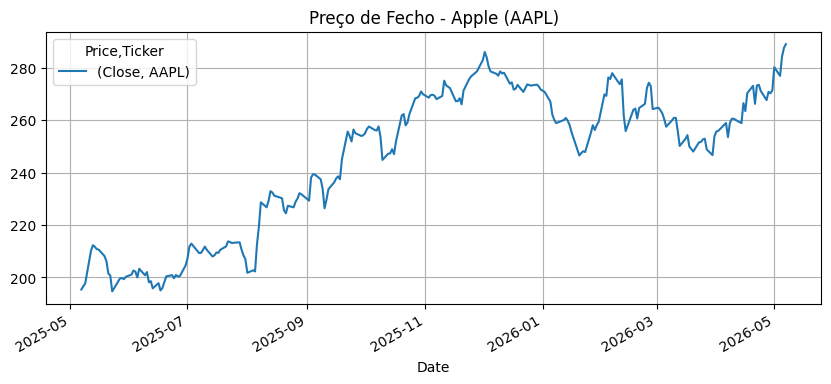

In [4]:
#Visualização
fecho.plot(title='Preço de Fecho - Apple (AAPL)', figsize=(10, 4))
plt.grid(True)
plt.show()

In [5]:
#Normalizar com MinMaxScaler
scaler = MinMaxScaler()
fecho_scaled = scaler.fit_transform(fecho)

In [6]:
#Criar dados sequenciais para LSTM
def cria_sequencias(dataset, n_steps):
    X, y = [], []
    for i in range(n_steps, len(dataset)):
        X.append(dataset[i - n_steps:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

n_steps = 20  # dias anteriores a usar
X, y = cria_sequencias(fecho_scaled, n_steps)

In [7]:
#Ajustar forma para LSTM [amostras, passos, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

In [8]:
#Criar modelo LSTM simples
modelo = Sequential()
modelo.add(LSTM(50, activation='relu', input_shape=(n_steps, 1)))
modelo.add(Dense(1))
modelo.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


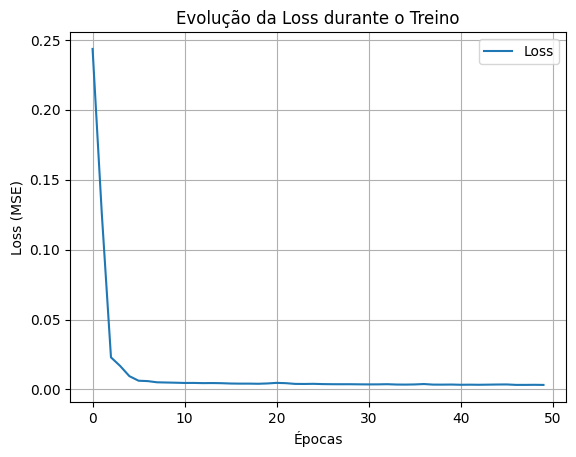

In [9]:
#Treinar o modelo
history = modelo.fit(X, y, epochs=50, verbose=0)

# 5. Plot da loss
plt.plot(history.history['loss'], label='Loss')
plt.title('Evolução da Loss durante o Treino')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
#Prever próximos N dias
n_dias_prever = 7
entrada = fecho_scaled[-n_steps:].reshape(1, n_steps, 1)
previsoes = []

for _ in range(n_dias_prever):
    prox_valor = modelo.predict(entrada)[0][0]
    previsoes.append(prox_valor)
    nova_entrada = np.append(entrada[:, 1:, :], [[[prox_valor]]], axis=1)
    entrada = nova_entrada

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [11]:
#Inverter normalização
previsoes = scaler.inverse_transform(np.array(previsoes).reshape(-1, 1))

In [12]:
#Criar índice temporal para os dias seguintes
ult_data = fecho.index[-1]
datas_prev = pd.date_range(start=ult_data + pd.Timedelta(days=1), periods=n_dias_prever, freq='B')  # Dias úteis


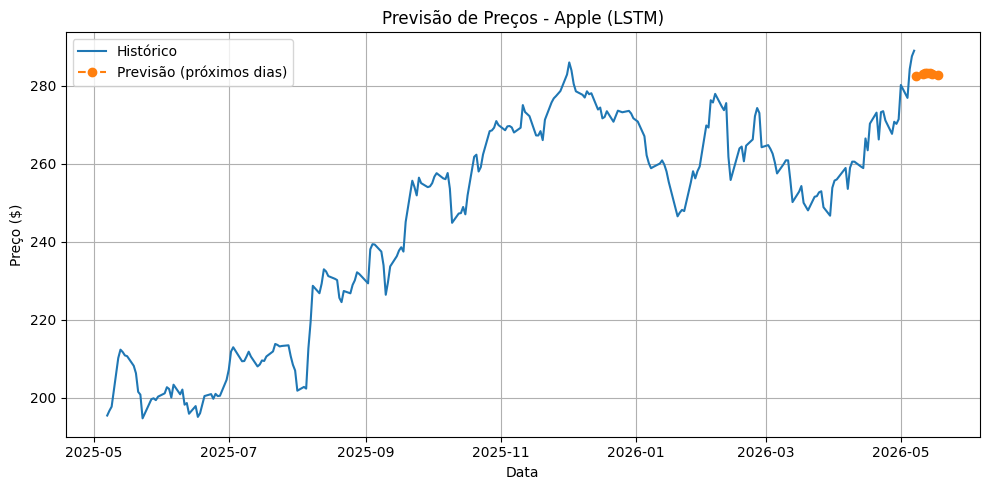

In [13]:
#Plot resultado
plt.figure(figsize=(10, 5))
plt.plot(fecho.index, fecho.values, label='Histórico')
plt.plot(datas_prev, previsoes, label='Previsão (próximos dias)', linestyle='--', marker='o')
plt.title('Previsão de Preços - Apple (LSTM)')
plt.xlabel('Data')
plt.ylabel('Preço ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()